# Check that changing the length of gates/the drive strength affects cross talk the way we expect 
- doesnt have to be super pretty
- obviously dont use time/freq interms of rabi

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [3]:
steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


In [4]:

import os
import sys


# --- PATH modification for TinyTeX (BEGIN) ---
tinytex_bin_path = os.path.expanduser("~/Library/TinyTeX/bin/universal-darwin")
if os.path.exists(tinytex_bin_path):
    if tinytex_bin_path not in os.environ['PATH']:
        os.environ['PATH'] = tinytex_bin_path + os.pathsep + os.environ['PATH']
        print(f"Added {tinytex_bin_path} to PATH for this Python session.")
    else:
        print(f"{tinytex_bin_path} already in PATH for this session.")
else:
    print(f"Warning: TinyTeX bin path not found at {tinytex_bin_path}. LaTeX rendering might fail.")
# --- PATH modification for TinyTeX (END) ---


# --- Matplotlib Configuration for LaTeX Integration ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}""",
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.titlesize": 12,
    "axes.titlesize": 10,
})



# --- Figure Dimensions for Your LaTeX Document ---
pt_to_inches = 1.0 / 72.27
latex_textwidth_pts = 469.75502 # Standard for A4 article, 10pt
latex_fig_width_inches =1 * latex_textwidth_pts * pt_to_inches  

# Calculate column width: (textwidth - columnsep) / 2
# Your LaTeX sets \columnsep to 0.75cm. Convert 0.75cm to points.
# column_sep_cm = 0.75
# column_sep_pts = column_sep_cm * (72.27 / 2.54) # 72.27 pts/inch, 2.54 cm/inch

# latex_column_width_pts = (latex_textwidth_pts - column_sep_pts) / 2

# # Set figure width to match the calculated column width
# latex_fig_width_inches = latex_column_width_pts * pt_to_inches


# latex_fig_height_inches = latex_fig_width_inches


/Users/archie/Library/TinyTeX/bin/universal-darwin already in PATH for this session.


# Find how params change with scaling rabi freq but keeping it a root X

Fitting parameters for 5.00 MHz: a = 18.41629936428021, b = 0.0002782705490643395


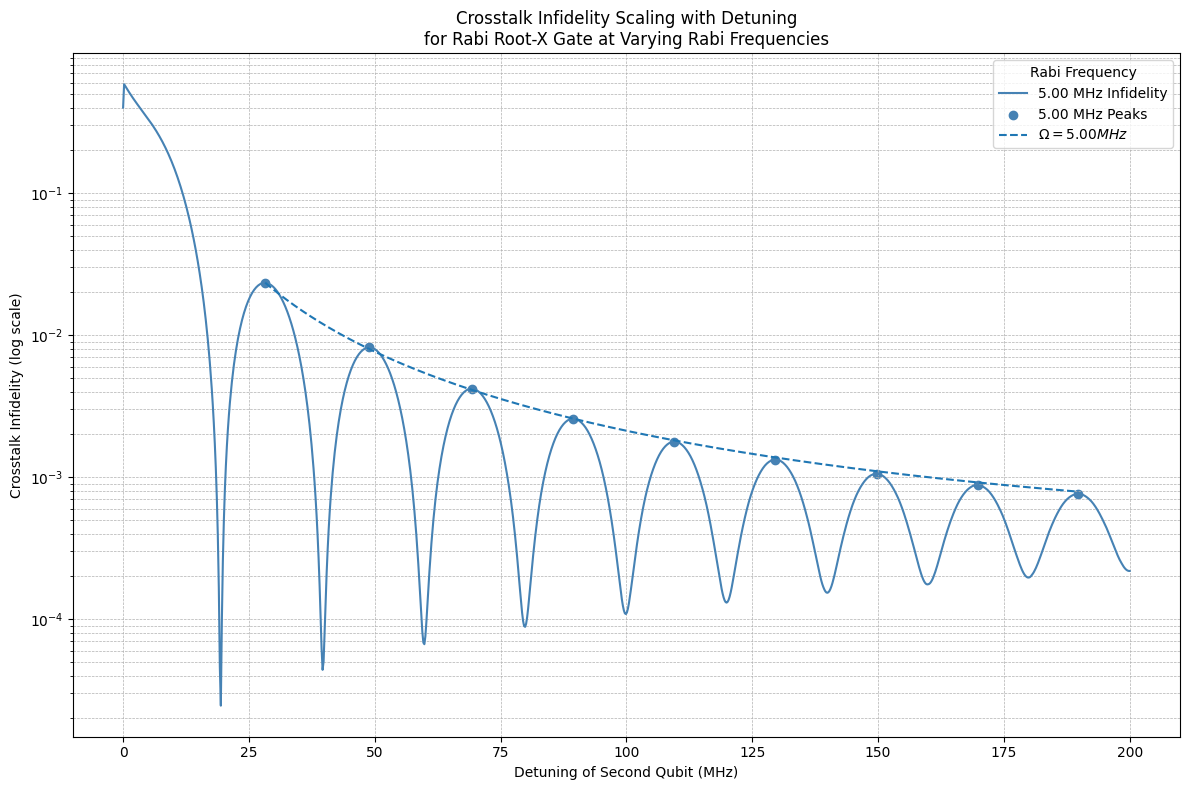

In [29]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10




# Integration parameters
tol = 10**-5
evaluation_points = 400

# Define the 1/x function for fitting
def inverse_function(x, a, b):
    return a / x**2 + b

# Function to find peaks, fit 1/x curve, and plot
def fit_and_plot(detunings, infidelities, label, color):
    # Find the peaks in the infidelity data
    peaks, _ = find_peaks(infidelities)

    # Extract the x (detunings) and y (infidelities) values at the peaks
    x_peaks = detunings[peaks][1:]
    y_peaks = infidelities[peaks][1:]

    # Fit the 1/x curve to the peaks
    params, _ = curve_fit(inverse_function, x_peaks, y_peaks)

    # Generate the fitted curve
    x_fit = np.linspace(min(x_peaks), max(x_peaks), 500)
    y_fit = inverse_function(x_fit, *params)
    a, b = params
    print(f"Fitting parameters for {label}: a = {a}, b = {b}")
    # Plot the results
    plt.semilogy(detunings, infidelities, label=f"{label} Infidelity", color=color)
    plt.scatter(x_peaks, y_peaks, color=color, marker='o', label=f"{label} Peaks")
    plt.semilogy(x_fit, y_fit, '--', label=f"$\\Omega= {label}$")







plt.figure(figsize=(12, 8))




for rabi_freq in np.linspace(0.005, 0.005, 1):
    evaluation_time = 1 / (4 * rabi_freq)
    detunings = np.linspace(0, 40 * rabi_freq, 1000)

    fids_1 = []
    fids_2 = []
    fids_combined = []

    times, Us_driving_frame = qt.calculate_unitaries(
        1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa,
        natural_freq=natural_freq + 0, driving_freq=driving_freq,
        rabi_freq=rabi_freq, atol=tol, rtol=tol
    )
    fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

    for detuning in detunings:
        times, Us_driving_frame = qt.calculate_unitaries(
            1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa,
            natural_freq=natural_freq + detuning, driving_freq=driving_freq,
            rabi_freq=rabi_freq, atol=tol, rtol=tol
        )

        fids_1.append(fid_1)

        effective_rabi_freq = np.sign(detuning) * np.sqrt(rabi_freq**2 + detuning**2)
        Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
        fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
        fids_2.append(fid_2)

        fid_combined = (np.abs((6 * fid_1 - 2) * (6 * fid_2 - 2)) + 4) / 20
        fids_combined.append(fid_combined)

    final_fids_combined_rabi = [fid[-1] for fid in fids_combined]

    # Convert rabi freq to MHz for the legend
    label_str = f"{rabi_freq * 1e3:.2f} MHz"
    fit_and_plot(detunings * 1e3, 1 - np.array(final_fids_combined_rabi), label_str, steel_blue)

# Plot formatting
plt.xlabel("Detuning of Second Qubit (MHz)")
plt.ylabel("Crosstalk Infidelity (log scale)")
plt.title("Crosstalk Infidelity Scaling with Detuning\nfor Rabi Root-X Gate at Varying Rabi Frequencies")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(title="Rabi Frequency")
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/fourier_scaling_unnormalised_rabi.png', dpi=600)
plt.show()

/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_4775/1368148941.py:17: RuntimeWarning: divide by zero encountered in divide
  return a / x**2 + b


Fitting parameters for 5.00 MHz: a = 18.41629936428021, b = 0.0002782705490643395
1
Fitting parameters for 3.83 MHz: a = 10.829663040578263, b = 0.0002364464223297279
Fitting parameters for 2.66 MHz: a = 5.2139353121369565, b = 0.0002368632318652044
Fitting parameters for 1.48 MHz: a = 1.6281711206318685, b = 0.0002374190338734047
Fitting parameters for 0.31 MHz: a = 0.07216756777889664, b = 0.00023633802603877305


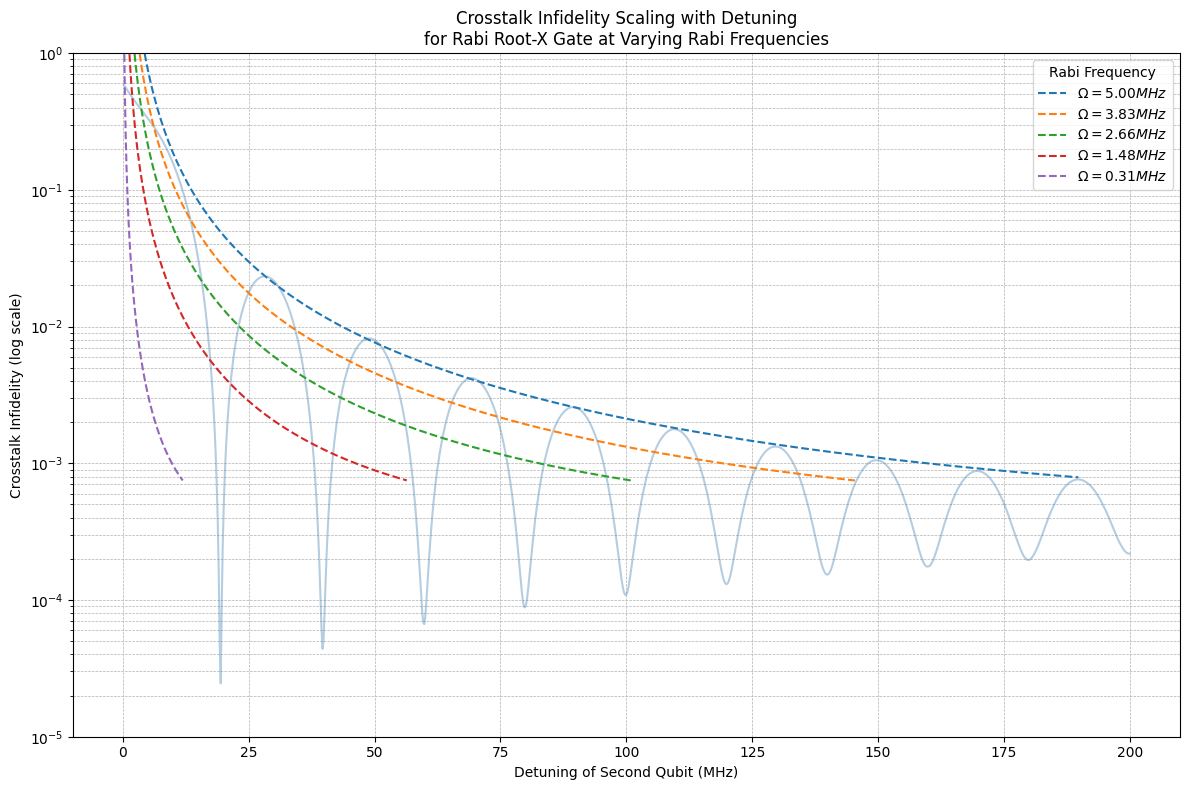

In [41]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10



# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-5
evaluation_points = 400

# Define the 1/x function for fitting
def inverse_function(x, a, b):
    return a / x**2 + b

# Function to find peaks, fit 1/x curve, and plot
def fit_and_plot(detunings, infidelities, label, color):
    # Find the peaks in the infidelity data
    peaks, _ = find_peaks(infidelities)

    # Extract the x (detunings) and y (infidelities) values at the peaks
    x_peaks = detunings[peaks][1:]
    y_peaks = infidelities[peaks][1:]

    # Fit the 1/x curve to the peaks
    params, _ = curve_fit(inverse_function, x_peaks, y_peaks)

    # Generate the fitted curve
    x_fit = np.linspace(0, max(x_peaks), 500)
    y_fit = inverse_function(x_fit, *params)
    a, b = params
    print(f"Fitting parameters for {label}: a = {a}, b = {b}")
    # Plot the results
    # plt.semilogy(detunings, infidelities, label=f"{label} Infidelity", color=color)
    # plt.scatter(x_peaks, y_peaks, color=color, marker='o', label=f"{label} Peaks")
    plt.semilogy(x_fit, y_fit, '--', label=f"$\\Omega= {label}$")
    # give this a ylim
    plt.ylim(1e-5, 1e0)







plt.figure(figsize=(12, 8))




for rabi_freq in np.linspace(0.005, 0.005/16, 5):
    evaluation_time = 1 / (4 * rabi_freq)
    detunings = np.linspace(0, 40 * rabi_freq, 100)

    if rabi_freq == 0.005:
        detunings = np.linspace(0, 40 * rabi_freq, 1000)
    fids_1 = []
    fids_2 = []
    fids_combined = []

    times, Us_driving_frame = qt.calculate_unitaries(
        1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa,
        natural_freq=natural_freq + 0, driving_freq=driving_freq,
        rabi_freq=rabi_freq, atol=tol, rtol=tol
    )
    fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

    for detuning in detunings:
        times, Us_driving_frame = qt.calculate_unitaries(
            1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa,
            natural_freq=natural_freq + detuning, driving_freq=driving_freq,
            rabi_freq=rabi_freq, atol=tol, rtol=tol
        )

        fids_1.append(fid_1)

        effective_rabi_freq = np.sign(detuning) * np.sqrt(rabi_freq**2 + detuning**2)
        Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
        fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
        fids_2.append(fid_2)

        fid_combined = (np.abs((6 * fid_1 - 2) * (6 * fid_2 - 2)) + 4) / 20
        fids_combined.append(fid_combined)

    final_fids_combined_rabi = [fid[-1] for fid in fids_combined]

    # Convert rabi freq to MHz for the legend
    label_str = f"{rabi_freq * 1e3:.2f} MHz"
    fit_and_plot(detunings * 1e3, 1 - np.array(final_fids_combined_rabi), label_str, steel_blue)
    # plot the final infidelity greyed out for the largest rabi frequency
    if rabi_freq == 0.005:
        # plot this only starting after where the first peak is
        # find the index of the first peak
        peaks, _ = find_peaks(1 - np.array(final_fids_combined_rabi))
        first_peak_index = peaks[0]
        print(first_peak_index)
        # plot the final infidelity greyed out

        # Slice the final_fids_combined_rabi starting from the first peak index
        sliced_final_fids = final_fids_combined_rabi[first_peak_index:]
        plt.semilogy(detunings[first_peak_index:] * 1e3, 1 - np.array(sliced_final_fids), color=steel_blue, alpha=0.4)


# Plot formatting
plt.xlabel("Detuning of Second Qubit (MHz)")
plt.ylabel("Crosstalk Infidelity (log scale)")
plt.title("Crosstalk Infidelity Scaling with Detuning\nfor Rabi Root-X Gate at Varying Rabi Frequencies")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(title="Rabi Frequency")
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/fourier_scaling_unnormalised_rabi.png', dpi=600)





plt.show()

Fitting parameters for 5.00 MHz: a = 18.41629936428021, b = 0.0002782705490643395
Fitting parameters for 5.00 MHz: a = 0.7366519745274775, b = 0.00027827055086968966
Fitting parameters for 3.83 MHz: a = 10.829663040578263, b = 0.0002364464223297279
Fitting parameters for 3.83 MHz: a = 0.7389970813497875, b = 0.00023644642426520873
Fitting parameters for 2.66 MHz: a = 5.2139353121369565, b = 0.0002368632318652044
Fitting parameters for 2.66 MHz: a = 0.7389715928568094, b = 0.0002368632353768452
Fitting parameters for 1.48 MHz: a = 1.6281711206318685, b = 0.0002374190338734047
Fitting parameters for 1.48 MHz: a = 0.7389461395835947, b = 0.000237419034546332
Fitting parameters for 0.31 MHz: a = 0.07216756777889664, b = 0.00023633802603877305
Fitting parameters for 0.31 MHz: a = 0.7389958941061004, b = 0.00023633802506808097


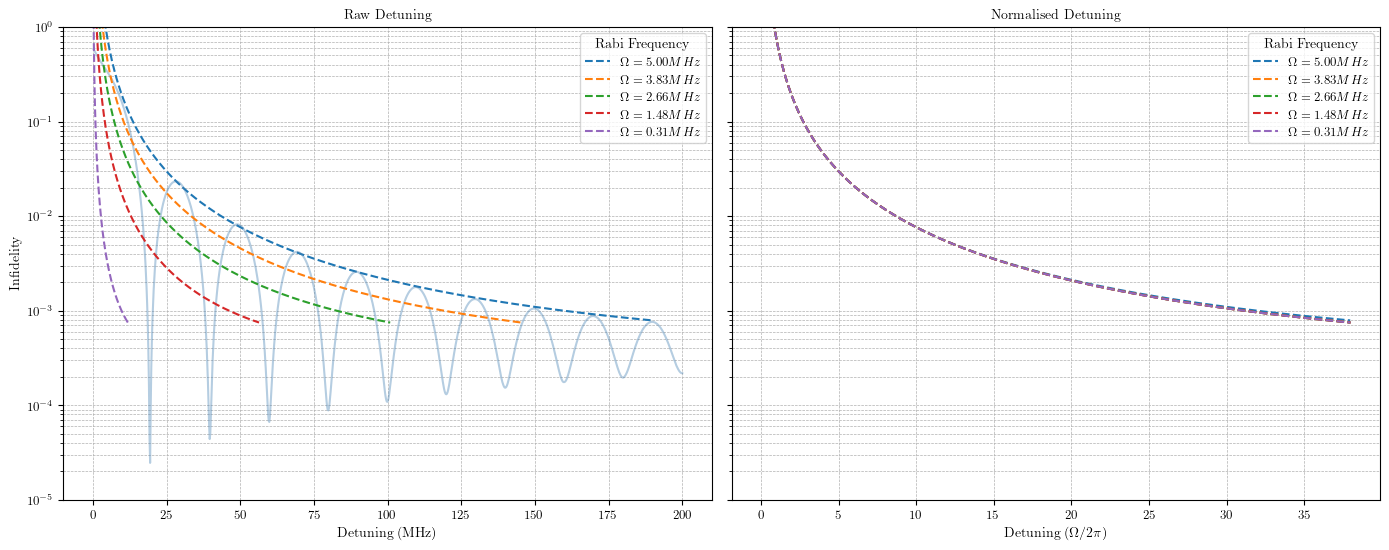

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks


steel_blue = 'steelblue'  # or define your custom colour

# Define the 1/x function for fitting
def inverse_function(x, a, b):
    return a / x**2 + b

def fit_and_plot(ax, detunings, infidelities, label, color):
    peaks, _ = find_peaks(infidelities)
    x_peaks = detunings[peaks][1:]
    y_peaks = infidelities[peaks][1:]
    params, _ = curve_fit(inverse_function, x_peaks, y_peaks)
    x_fit = np.linspace(0.01, max(x_peaks), 500)
    y_fit = inverse_function(x_fit, *params)
    print(f"Fitting parameters for {label}: a = {params[0]}, b = {params[1]}")
    ax.semilogy(x_fit, y_fit, '--', label=f"$\\Omega = {label}$")
    ax.set_ylim(1e-5, 1e0)

# Plot configuration
fig, axs = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

# Loop over Rabi frequencies
for rabi_freq in np.linspace(0.005, 0.005/16, 5):
    evaluation_time = 1 / (4 * rabi_freq)
    detunings = np.linspace(0, 40 * rabi_freq, 1000 if rabi_freq == 0.005 else 100)
    fids_combined = []

    # Ideal gate
    times, Us_driving_frame = qt.calculate_unitaries(
        1, evaluation_time, 400, hamiltonians.rabi_rwa,
        natural_freq=10, driving_freq=10, rabi_freq=rabi_freq, atol=1e-5, rtol=1e-5
    )
    fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

    for detuning in detunings:
        times, Us_detuned = qt.calculate_unitaries(
            1, evaluation_time, 400, hamiltonians.rabi_rwa,
            natural_freq=10 + detuning, driving_freq=10,
            rabi_freq=rabi_freq, atol=1e-5, rtol=1e-5
        )
        eff_rabi = np.sign(detuning) * np.sqrt(rabi_freq**2 + detuning**2)
        Us_eff = qt.phase_boost_unitaries(Us_detuned, -eff_rabi, times)
        fid_2 = qt.calculate_fidelities(np.eye(2), Us_eff, 2)
        fid_combined = (np.abs((6 * fid_1 - 2) * (6 * fid_2 - 2)) + 4) / 20
        fids_combined.append(fid_combined)

    final_fids = np.array([f[-1] for f in fids_combined])
    label_str = f"{rabi_freq * 1e3:.2f} MHz"

    # Panel A – raw detuning
    fit_and_plot(axs[0], detunings * 1e3, 1 - final_fids, label_str, steel_blue)
    if rabi_freq == 0.005:
        peaks, _ = find_peaks(1 - final_fids)
        first_peak_index = peaks[0]
        axs[0].semilogy(detunings[first_peak_index:] * 1e3,
                        1 - final_fids[first_peak_index:], color=steel_blue, alpha=0.4)

    # Panel B – normalised detuning
    fit_and_plot(axs[1], detunings / rabi_freq, 1 - final_fids, label_str, steel_blue)

# Panel A formatting
axs[0].set_title("Raw Detuning")
axs[0].set_xlabel("Detuning (MHz)")
axs[0].set_ylabel("Infidelity")
axs[0].grid(True, which="both", linestyle="--", linewidth=0.5)
axs[0].legend(title="Rabi Frequency")

# Panel B formatting
axs[1].set_title("Normalised Detuning")
axs[1].set_xlabel(r"Detuning ($\Omega/2\pi$)")
axs[1].grid(True, which="both", linestyle="--", linewidth=0.5)
axs[1].legend(title="Rabi Frequency")

# Final layout and save
# fig.suptitle("Crosstalk Infidelity Scaling with Detuning for Rabi Root-X Gate at Varying Rabi Frequencies")
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.savefig('/Users/archie/documents/year4/project/Figures_Final/fourier_scaling_split_panel.pdf', dpi=600)
plt.show()

## To note here
- it is actually 1/x^2 scaling - I suppose this was known/expected from th powerspectrum of a top hat
- we see cross talk is larger at larger detunings for larger rabi frequency
- that is to say we can compress the above plots to look the same (within error) by plotting them with their normalised detuning (ie interms of their rabi freq)
- yeah so if you are 40*rabi freq away from any of these you will get the same crosstalk

# Repeat for CCD - out of interest mainly

/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_4775/105260828.py:13: RuntimeWarning: divide by zero encountered in divide
  return a / x**2 + b


Fitting parameters for 5.00 MHz: a = 3.8728444180674955, b = 0.01277353247046221
Fitting parameters for 5.00 MHz: a = 0.15491377740232937, b = 0.01277353217727184
Fitting parameters for 3.83 MHz: a = 2.036108931052174, b = 0.010958203337271821
Fitting parameters for 3.83 MHz: a = 0.13894047576301738, b = 0.010958203338548578
Fitting parameters for 2.66 MHz: a = 1.1590165416610954, b = 0.008824098758540625
Fitting parameters for 2.66 MHz: a = 0.16426753493606944, b = 0.008824098395515805
Fitting parameters for 1.48 MHz: a = 0.8839799564275683, b = 0.0070355727393220935
Fitting parameters for 1.48 MHz: a = 0.40119466965293543, b = 0.007035572747865739
Fitting parameters for 0.31 MHz: a = 0.058992829815713764, b = 0.004930586725425694
Fitting parameters for 0.31 MHz: a = 0.6040865772154322, b = 0.004930586735415123


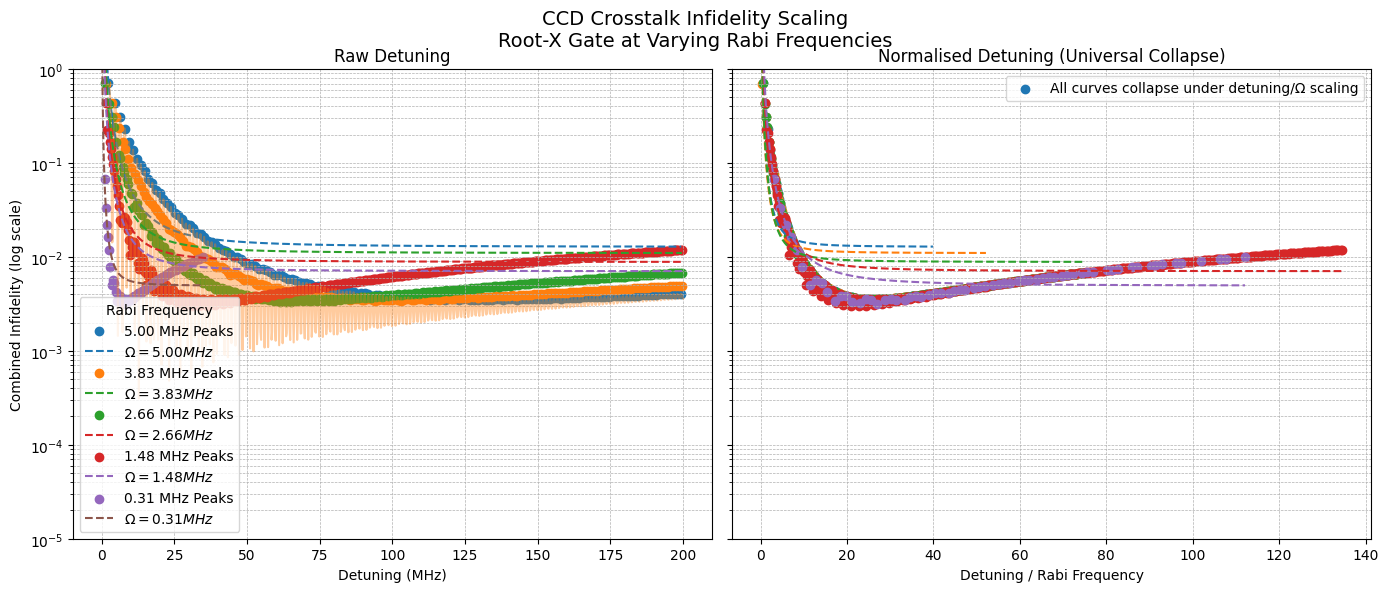

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# Assumed imports
# from spin_tools import quantum_tools as qt, hamiltonians
# from spin_tools.gates import root_x
# from your_module import ccd_floquet

# Plot fitting helper
def inverse_function(x, a, b):
    return a / x**2 + b

def fit_and_plot(ax, detunings, infidelities, label):
    peaks, _ = find_peaks(infidelities)
    x_peaks = detunings[peaks][1:]
    y_peaks = infidelities[peaks][1:]
    if len(x_peaks) < 3:
        return  # Avoid bad fits on sparse data
    params, _ = curve_fit(inverse_function, x_peaks, y_peaks)
    x_fit = np.linspace(0.00, max(x_peaks), 500)
    y_fit = inverse_function(x_fit, *params)
    print(f"Fitting parameters for {label}: a = {params[0]}, b = {params[1]}")

    # plot the peaks on a scatter
    ax.scatter(x_peaks, y_peaks, marker='o', label=f"{label} Peaks")
    ax.semilogy(x_fit, y_fit, '--', label=f"$\\Omega = {label}$")
    ax.set_ylim(1e-5, 1e0)

# Figure setup
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)


theta_m = -0.49999999968816566 * np.pi
phi_0 = 0.48507178492998143 * np.pi
# Main loop over Rabi frequencies
for rabi_freq in np.linspace(0.005, 0.005/16, 5):
    
    epsilon_m = rabi_freq / 16
    phase_freq = rabi_freq
    

    tol = 1e-5
    evaluation_points = 1000
    evaluation_time = 4 / rabi_freq
    detunings = np.linspace(0, 0.2, 1000)

    fids_combined = []

    # Qubit 1 evolution (ideal root-X gate)
    times, Us_driving_frame = qt.calculate_unitaries(
        1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
        driving_freq=10, natural_freq=10,
        rabi_freq=rabi_freq, phi_0=phi_0, epsilon_m=epsilon_m,
        phase_freq=phase_freq, theta_m=theta_m,
        atol=tol, rtol=tol
    )
    fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

    # Qubit 2 detuned runs
    for detuning in detunings:
        times, Us_detuned = qt.calculate_unitaries(
            1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
            driving_freq=10, natural_freq=10 - detuning,
            rabi_freq=rabi_freq, phi_0=phi_0, epsilon_m=epsilon_m,
            phase_freq=phase_freq, theta_m=theta_m,
            atol=tol, rtol=tol
        )

        ccd_freq = np.sign(detuning) * 2 * ccd_floquet(
            10 - detuning, 10, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m
        )[4]
        Us_boosted = qt.phase_boost_unitaries(Us_detuned, ccd_freq, times)
        fid_2 = qt.calculate_fidelities(np.eye(2), Us_boosted, 2)
        fid_combined = (np.abs((6 * fid_1 - 2) * (6 * fid_2 - 2)) + 4) / 20
        fids_combined.append(fid_combined)

    final_fids = np.array([f[-1] for f in fids_combined])
    label_str = f"{rabi_freq * 1e3:.2f} MHz"

    # Default colour cycling


    # Panel A – raw detuning
    fit_and_plot(axs[0], detunings * 1e3, 1 - final_fids, label_str)
    if rabi_freq == 0.005:
        peaks, _ = find_peaks(1 - final_fids)
        first_peak_index = peaks[0]
        axs[0].semilogy(detunings[first_peak_index:] * 1e3,
                        1 - final_fids[first_peak_index:],  alpha=0.4)

    # Panel B – normalised detuning
    fit_and_plot(axs[1], detunings / rabi_freq, 1 - final_fids, label_str)

# Panel A formatting
axs[0].set_title("Raw Detuning")
axs[0].set_xlabel("Detuning (MHz)")
axs[0].set_ylabel("Combined Infidelity (log scale)")
axs[0].grid(True, which="both", linestyle="--", linewidth=0.5)
axs[0].legend(title="Rabi Frequency")

# Panel B formatting
axs[1].set_title("Normalised Detuning (Universal Collapse)")
axs[1].set_xlabel("Detuning / Rabi Frequency")
axs[1].grid(True, which="both", linestyle="--", linewidth=0.5)
axs[1].legend(["All curves collapse under detuning/Ω scaling"])

# Layout and save
fig.suptitle("CCD Crosstalk Infidelity Scaling\nRoot-X Gate at Varying Rabi Frequencies", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.savefig('/Users/archie/documents/year4/project/Figures/fourier_scaling_ccd_split_panel.png', dpi=600)
plt.show()

# Is detuning the same as time??
- for the same detuning - vary time
- for same time vary detuning

- this is only for the second qubit - ie not combined fidelity

## Detunings

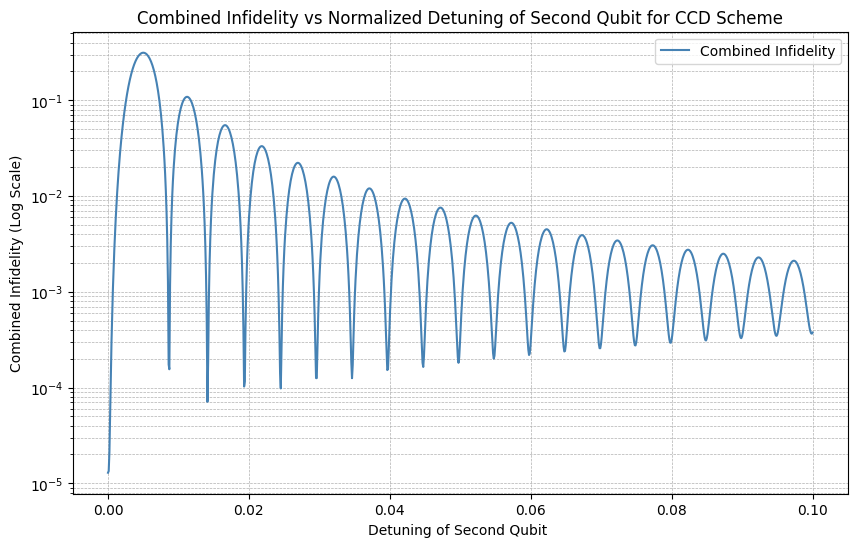

In [76]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-5
evaluation_points = 200


evaluation_time = 1/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 0.1, 1000)



fids_1 = []
fids_2 = []
fids_combined = []



for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq, atol=tol, rtol=tol)


    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)



# Extract the final time step fidelity for each detuning
final_fids_2_rabi = [fid[-1] for fid in fids_2]


# Plot the results
# find combdined infidelity
infidelities_2_rabi = 1-np.array(final_fids_2_rabi)



# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_rabi, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning of Second Qubit ")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


## Time

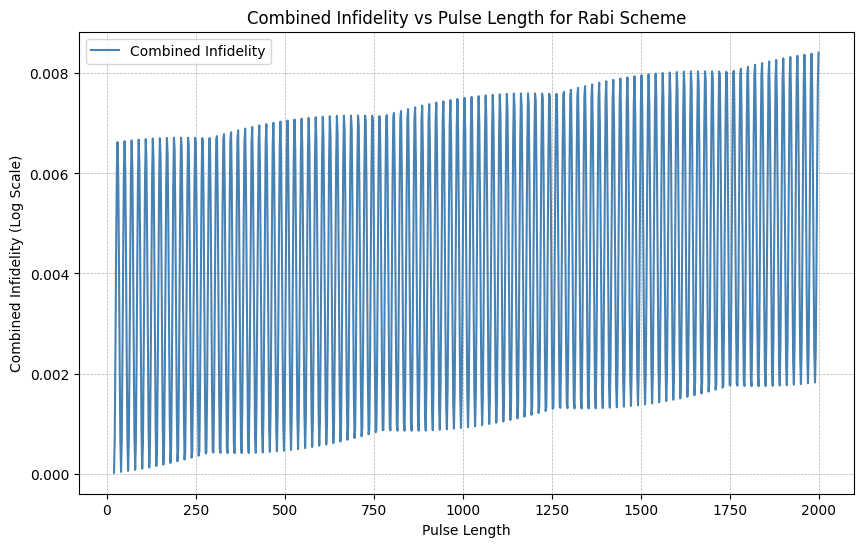

In [77]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-5
evaluation_points = 200


evaluation_times = np.linspace(0.1, 10, 1000)/rabi_freq


# iteration parameters
detuning  = 0.05



fids_1 = []
fids_2 = []
fids_combined = []



for evaluation_time in evaluation_times:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq, atol=tol, rtol=tol)


    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)



# Extract the final time step fidelity for each detuning
final_fids_2_rabi = [fid[-1] for fid in fids_2]


# Plot the results
# find combdined infidelity
infidelities_2_rabi = 1-np.array(final_fids_2_rabi)



# Plot combined infidelity vs evaluation time on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.plot(evaluation_times, infidelities_2_rabi, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Pulse Length")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Pulse Length for Rabi Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


Ah yes - the fidelity is only realy relevant at the points we do the gat we are testing for

$\left(\frac{2Ax\sin\left(x\cdot0.3\right)}{\left(x\cdot0.3\right)}\right)^{2}$ - if you plot this you see that it is just sin - and that is the power spectrum at a specific detuning with varying pulse length

# So I think Ignore the first qubit ad just plot this stuff vs rabi with exactly the same values

In [81]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)

fids_1 = []
fids_2 = []
fids_combined = []



# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:

    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    


# Extract the final time step fidelity for each detuning
final_fids_2_ccd = [fid[-1] for fid in fids_2]

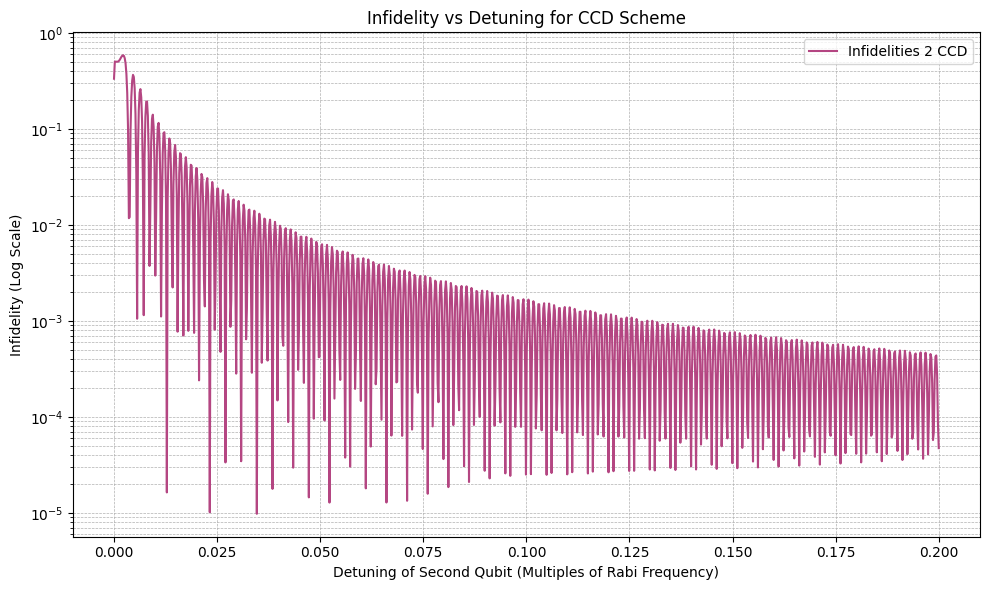

In [ ]:
# Plot the results
infidelities_2_ccd = 1 - np.array(final_fids_2_ccd)  # Calculate infidelities
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_ccd, label="Infidelities 2 CCD", color=plum)
plt.xlabel("Detuning of Second Qubit")
plt.ylabel("Infidelity (Log Scale)")
plt.title("Infidelity vs Detuning for CCD Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)



fids_1 = []
fids_2 = []
fids_combined = []



for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)


    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)

# Extract the final time step fidelity for each detuning
final_fids_2_rabi = [fid[-1] for fid in fids_2]


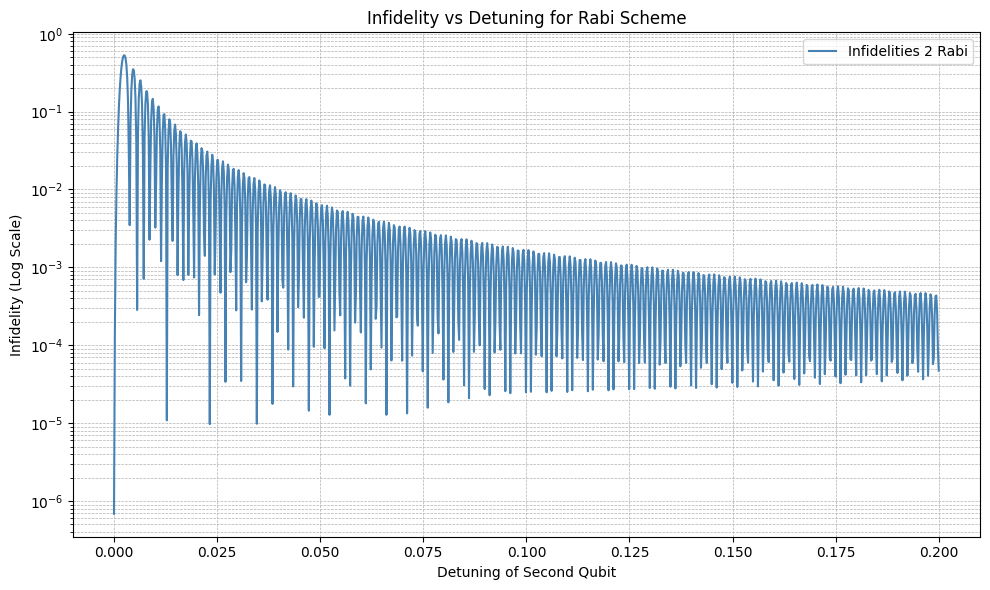

In [89]:
# Plot the results
infidelities_2_rabi = 1 - np.array(final_fids_2_rabi)  # Calculate infidelities
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_rabi, label="Infidelities 2 Rabi", color=steel_blue)
plt.xlabel("Detuning of Second Qubit")
plt.ylabel("Infidelity (Log Scale)")
plt.title("Infidelity vs Detuning for Rabi Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

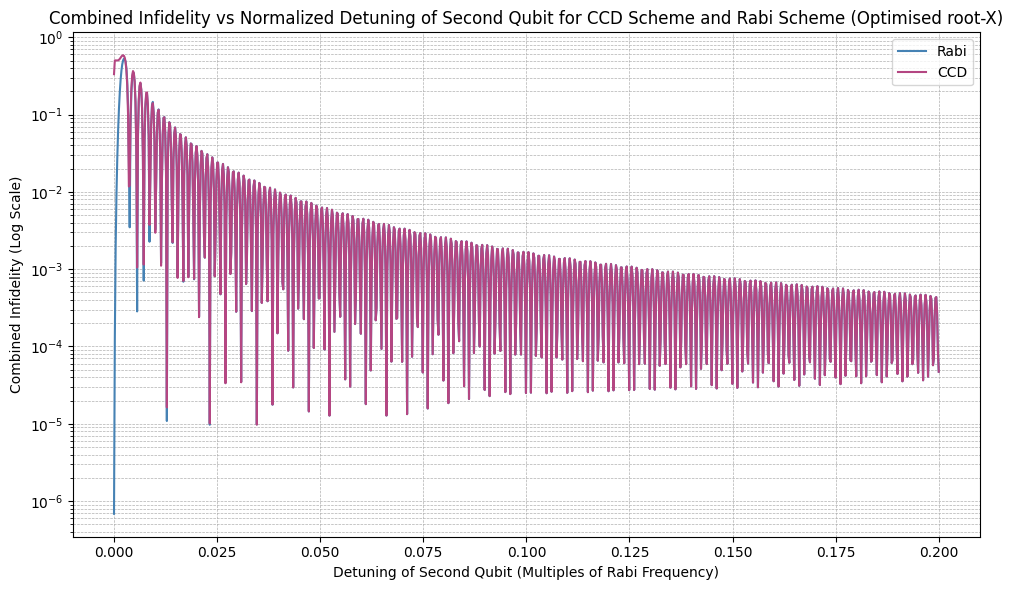

In [91]:
# find combdined infidelity
infidelities_2_ccd = 1-np.array(final_fids_2_ccd)
infidelities_2_rabi = 1-np.array(final_fids_2_rabi)



# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_rabi, label="Rabi", color=steel_blue)
plt.semilogy(detunings, infidelities_2_ccd, label="CCD", color=plum)

plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Optimised root-X)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
#plt.savefig("dirty_root_x_scaling.png", dpi=300)
plt.show()

